In [1]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE

from umap import UMAP

import pandas as pd
import numpy as np

from config import *
from pandas.api.types import CategoricalDtype
import scipy.sparse as sparse
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

from functools import reduce
from sklearn.base import BaseEstimator, TransformerMixin


class DOWEncoder(BaseEstimator, TransformerMixin):
    """Encodes an int denoting DOW (1-7), to polar coordinates, allowing cyclic features representation"""
    def __init__(self, return_pd = True) -> pd.DataFrame:
        self.return_pd = return_pd
        return

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        def encode_day(day):
            rad = 2*np.pi*day / 7
            return np.round(np.cos(rad),3), np.round(np.sin(rad),3)
        X["X_day_dir"], X["Y_day_dir"] = zip(*X["order_dow"].apply(encode_day))
        X = X.drop("order_dow",axis=1)
        if self.return_pd:
            return X.copy()
        return X


class HourOfDayEncoder(BaseEstimator, TransformerMixin):
    """Encodes an int denoting hour (0-24), to polar coordinates, allowing cyclic features representation"""
    def __init__(self, return_pd = True):
        self.return_pd = return_pd
        return

    def fit(self, X, y=None):
        return self
    
    def transform(self, X) -> pd.DataFrame:
        def encode_hour(HourOfDay: int):
            rad = 2*np.pi*HourOfDay / 24
            return np.round(np.cos(rad),3), np.round(np.sin(rad),3)
        X["X_hour_dir"], X["Y_hour_dir"] = zip(*X["order_hour_of_day"].apply(encode_hour))
        X = X.drop("order_hour_of_day",axis=1)
        if self.return_pd:
            return X.copy()
        return X

/Users/krusand/Documents/GitHub/02807-CT-Project/.venv/lib/python3.10/site-packages/llvmlite/binding/ffi.py:175: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/Users/krusand/Documents/GitHub/02807-CT-Project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Features

The following features will be implemented: 

- Number of orders a user has made: _are they a shopper who orders a lot, or a shopper with fewer orders?_
- Avg number of products in baskets: _do they shop small baskets or large baskets? -> family or single_
- User frequency: _how often does the user shop?_
- Reorder frequency: Same product types?

Sebastian:
- Avg hour of day
- Avg dow

Possibly: 
- Frequency of department id -> which product types do they buy?



In [2]:
orders = pd.read_parquet(ORDERS_PATH)
orders_products = pd.read_parquet(ORDER_PRODUCTS__TRAIN_PATH)
orders_orders_products = orders.merge(orders_products, how='inner',on = 'order_id')
products = pd.read_parquet(PRODUCTS_PATH)
departments = pd.read_parquet(DEPARTMENTS_PATH)
aisle = pd.read_parquet(AISLES_PATH)

In [3]:
order_all_info = (orders_orders_products
 .merge(products, how='inner', on='product_id')
 .merge(departments, how='inner', on ='department_id')
 .merge(aisle, how='inner', on ='aisle_id')
)

In [ ]:


n_orders = (orders
              .groupby(["user_id"])
              .size()
              .reset_index(name="n_orders_u"))

products_pr_order = (orders_orders_products
 .groupby(["user_id", "order_id"])
 ["product_id"]
 .size()
 .reset_index(name='n_products_pr_order')
 .groupby(["user_id"])
 ["n_products_pr_order"]
 .mean()
 .reset_index(name='avg_products_pr_order')
 )



order_frequency = (orders
 .groupby(["user_id"])
 ["days_since_prior_order"]
 .mean()
 .reset_index(name='avg_days_since_prior_order')
 )

reorders = (orders_orders_products
 .groupby(["user_id"])
 .agg(n_products = ('reordered', 'size'),
      n_reorders = ('reordered', 'sum')
      )
 .reset_index()
 .assign(frac_reorders = lambda x: x["n_reorders"]/x['n_products'])
 )

hour_enc = HourOfDayEncoder(return_pd=True)
avg_order_of_hour = (hour_enc
          .fit_transform(orders)
          .groupby(["user_id"])
          .agg(avg_x_hour = ('X_hour_dir', 'mean'),
               avg_y_hour = ('Y_hour_dir', 'mean')
               )
          .reset_index()
          )

dow_enc = DOWEncoder(return_pd=True)
avg_order_dow = (dow_enc
          .fit_transform(X=orders)
          .groupby(["user_id"])
          .agg(avg_x_dow = ('X_day_dir', 'mean'),
               avg_y_dow = ('Y_day_dir', 'mean')
               )
          .reset_index()
          )


In [5]:

X = reduce(lambda x,y: pd.merge(x,y, on='user_id')
        , [n_orders, products_pr_order, order_frequency, reorders, avg_order_dow, avg_order_of_hour, frac_department])[["n_orders_u", "avg_products_pr_order", "avg_days_since_prior_order", "frac_reorders", "avg_x_dow", "avg_y_dow", "avg_x_hour", "avg_y_hour", 'dep_id_1', 'dep_id_2', 'dep_id_3', 'dep_id_4', 'dep_id_5', 'dep_id_6', 'dep_id_7', 'dep_id_8', 'dep_id_9', 'dep_id_10', 'dep_id_11', 'dep_id_12', 'dep_id_13', 'dep_id_14', 'dep_id_15', 'dep_id_16', 'dep_id_17', 'dep_id_18', 'dep_id_19', 'dep_id_20','dep_id_21']]
X

,n_orders_u,avg_products_pr_order,avg_days_since_prior_order,frac_reorders,avg_x_dow,avg_y_dow,avg_x_hour,avg_y_hour,dep_id_1,dep_id_2,...,dep_id_12,dep_id_13,dep_id_14,dep_id_15,dep_id_16,dep_id_17,dep_id_18,dep_id_19,dep_id_20,dep_id_21
0,11,11.0,19.000000,0.909091,-0.362091,0.311636,-0.550636,0.375455,0.000000,0.0,...,0.000000,0.000000,0.090909,0.000000,0.363636,0.090909,0.0,0.272727,0.000000,0.000000
1,15,31.0,16.285714,0.387097,-0.020200,0.601733,-0.865867,0.347267,0.354839,0.0,...,0.000000,0.000000,0.000000,0.096774,0.032258,0.000000,0.0,0.161290,0.096774,0.000000
2,5,9.0,11.500000,0.444444,0.164200,0.330000,-0.493200,-0.521400,0.000000,0.0,...,0.000000,0.111111,0.000000,0.000000,0.111111,0.111111,0.0,0.000000,0.000000,0.000000
3,21,9.0,10.450000,0.888889,0.239000,0.278048,-0.558952,-0.213857,0.000000,0.0,...,0.111111,0.111111,0.000000,0.000000,0.111111,0.000000,0.0,0.000000,0.000000,0.000000
4,4,18.0,23.333333,0.222222,0.411500,-0.048250,0.158500,0.091500,0.000000,0.0,...,0.000000,0.055556,0.000000,0.055556,0.055556,0.000000,0.0,0.000000,0.055556,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131204,20,22.0,16.947368,0.636364,-0.077550,0.095100,-0.359800,-0.535150,0.045455,0.0,...,0.000000,0.045455,0.045455,0.000000,0.090909,0.000000,0.0,0.454545,0.000000,0.045455
131205,24,19.0,8.826087,0.578947,0.264958,0.154875,-0.109875,-0.386667,0.157895,0.0,...,0.000000,0.052632,0.000000,0.000000,0.052632,0.000000,0.0,0.105263,0.000000,0.052632
131206,6,13.0,29.400000,0.923077,0.149833,0.188333,-0.362167,-0.725000,0.076923,0.0,...,0.000000,0.000000,0.000000,0.000000,0.230769,0.000000,0.0,0.230769,0.000000,0.000000
131207,4,19.0,16.666667,0.315789,-0.181000,0.087000,-0.676750,-0.609750,0.052632,0.0,...,0.000000,0.052632,0.000000,0.000000,0.315789,0.000000,0.0,0.000000,0.105263,0.052632


# Clustering and dimensionality reduction for plotting

In [4]:


products_pr_user = (orders_orders_products
 .groupby(["user_id"])
 ["product_id"]
 .size()
 .reset_index(name="n_products_pr_user")
 )


products_pr_user_pr_department = (order_all_info
 .groupby(["user_id", "department_id"])
 .size()
 .reset_index(name='n_products')
 )

frac_department = (products_pr_user_pr_department
 .merge(products_pr_user, on ='user_id', how='inner')
 .assign(frac_products_in_department = lambda x: x['n_products'] / x["n_products_pr_user"])
 [["user_id", "department_id", "frac_products_in_department"]]
 .pivot(index='user_id', columns='department_id', values="frac_products_in_department")
 .fillna(0)
)
frac_department.columns = [f"dep_id_{i}" for i in frac_department.columns]
frac_department = frac_department.reset_index()


X_sample = frac_department.drop("user_id", axis=1).sample(50000)

In [5]:
dbscan = DBSCAN()
y = dbscan.fit_predict(X_sample)


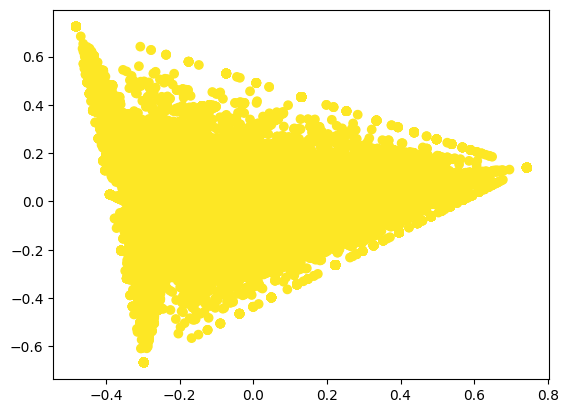

In [6]:
pca = PCA(n_components=2)
X_reduced_pca = pca.fit_transform(X_sample)

plt.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=y)

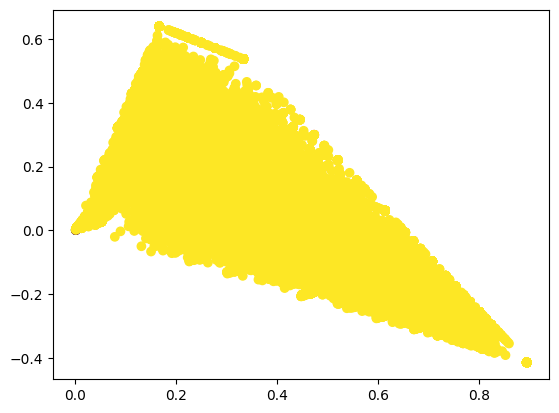

In [11]:
svd = TruncatedSVD(n_components=2)
X_reduced_svd = svd.fit_transform(X_sample)

plt.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=y)

In [8]:
tsne = TSNE(n_components = 2, verbose=10, n_jobs=-1)
X_reduced_tsne = tsne.fit_transform(X_sample)
dbscan = DBSCAN()
)

plt.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=y)

SyntaxError: unmatched ')' (733018405.py, line 4)

UMAP( verbose=True)
Sat Nov 22 14:01:17 2025 Construct fuzzy simplicial set
Sat Nov 22 14:01:17 2025 Finding Nearest Neighbors
Sat Nov 22 14:01:17 2025 Building RP forest with 23 trees
Sat Nov 22 14:01:17 2025 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	Stopping threshold met -- exiting after 2 iterations
Sat Nov 22 14:01:19 2025 Finished Nearest Neighbor Search
Sat Nov 22 14:01:19 2025 Construct embedding


Epochs completed:   2%| ▏          3/200 [00:00]

	completed  0  /  200 epochs


Epochs completed:  12%| █▏         24/200 [00:01]

	completed  20  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  91%| █████████  182/200 [00:09]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:10]

Sat Nov 22 14:02:08 2025 Finished embedding


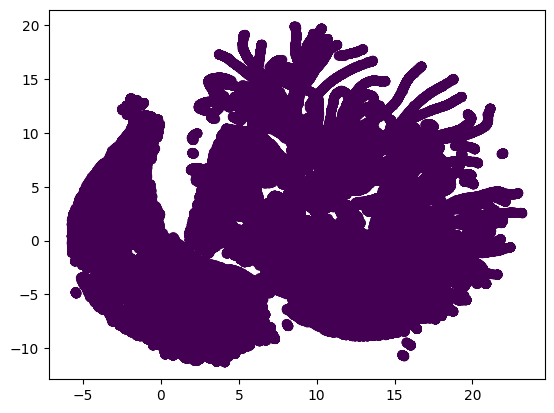

In [ ]:

umap = UMAP(n_components=2, verbose=True, n_jobs=-1)
X_reduced_umap = umap.fit_transform(X_sample)
dbscan = DBSCAN()

plt.scatter(X_reduced_umap[:,0], X_reduced_umap[:,1], c=y)

/Users/krusand/Documents/GitHub/02807-CT-Project/.venv/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


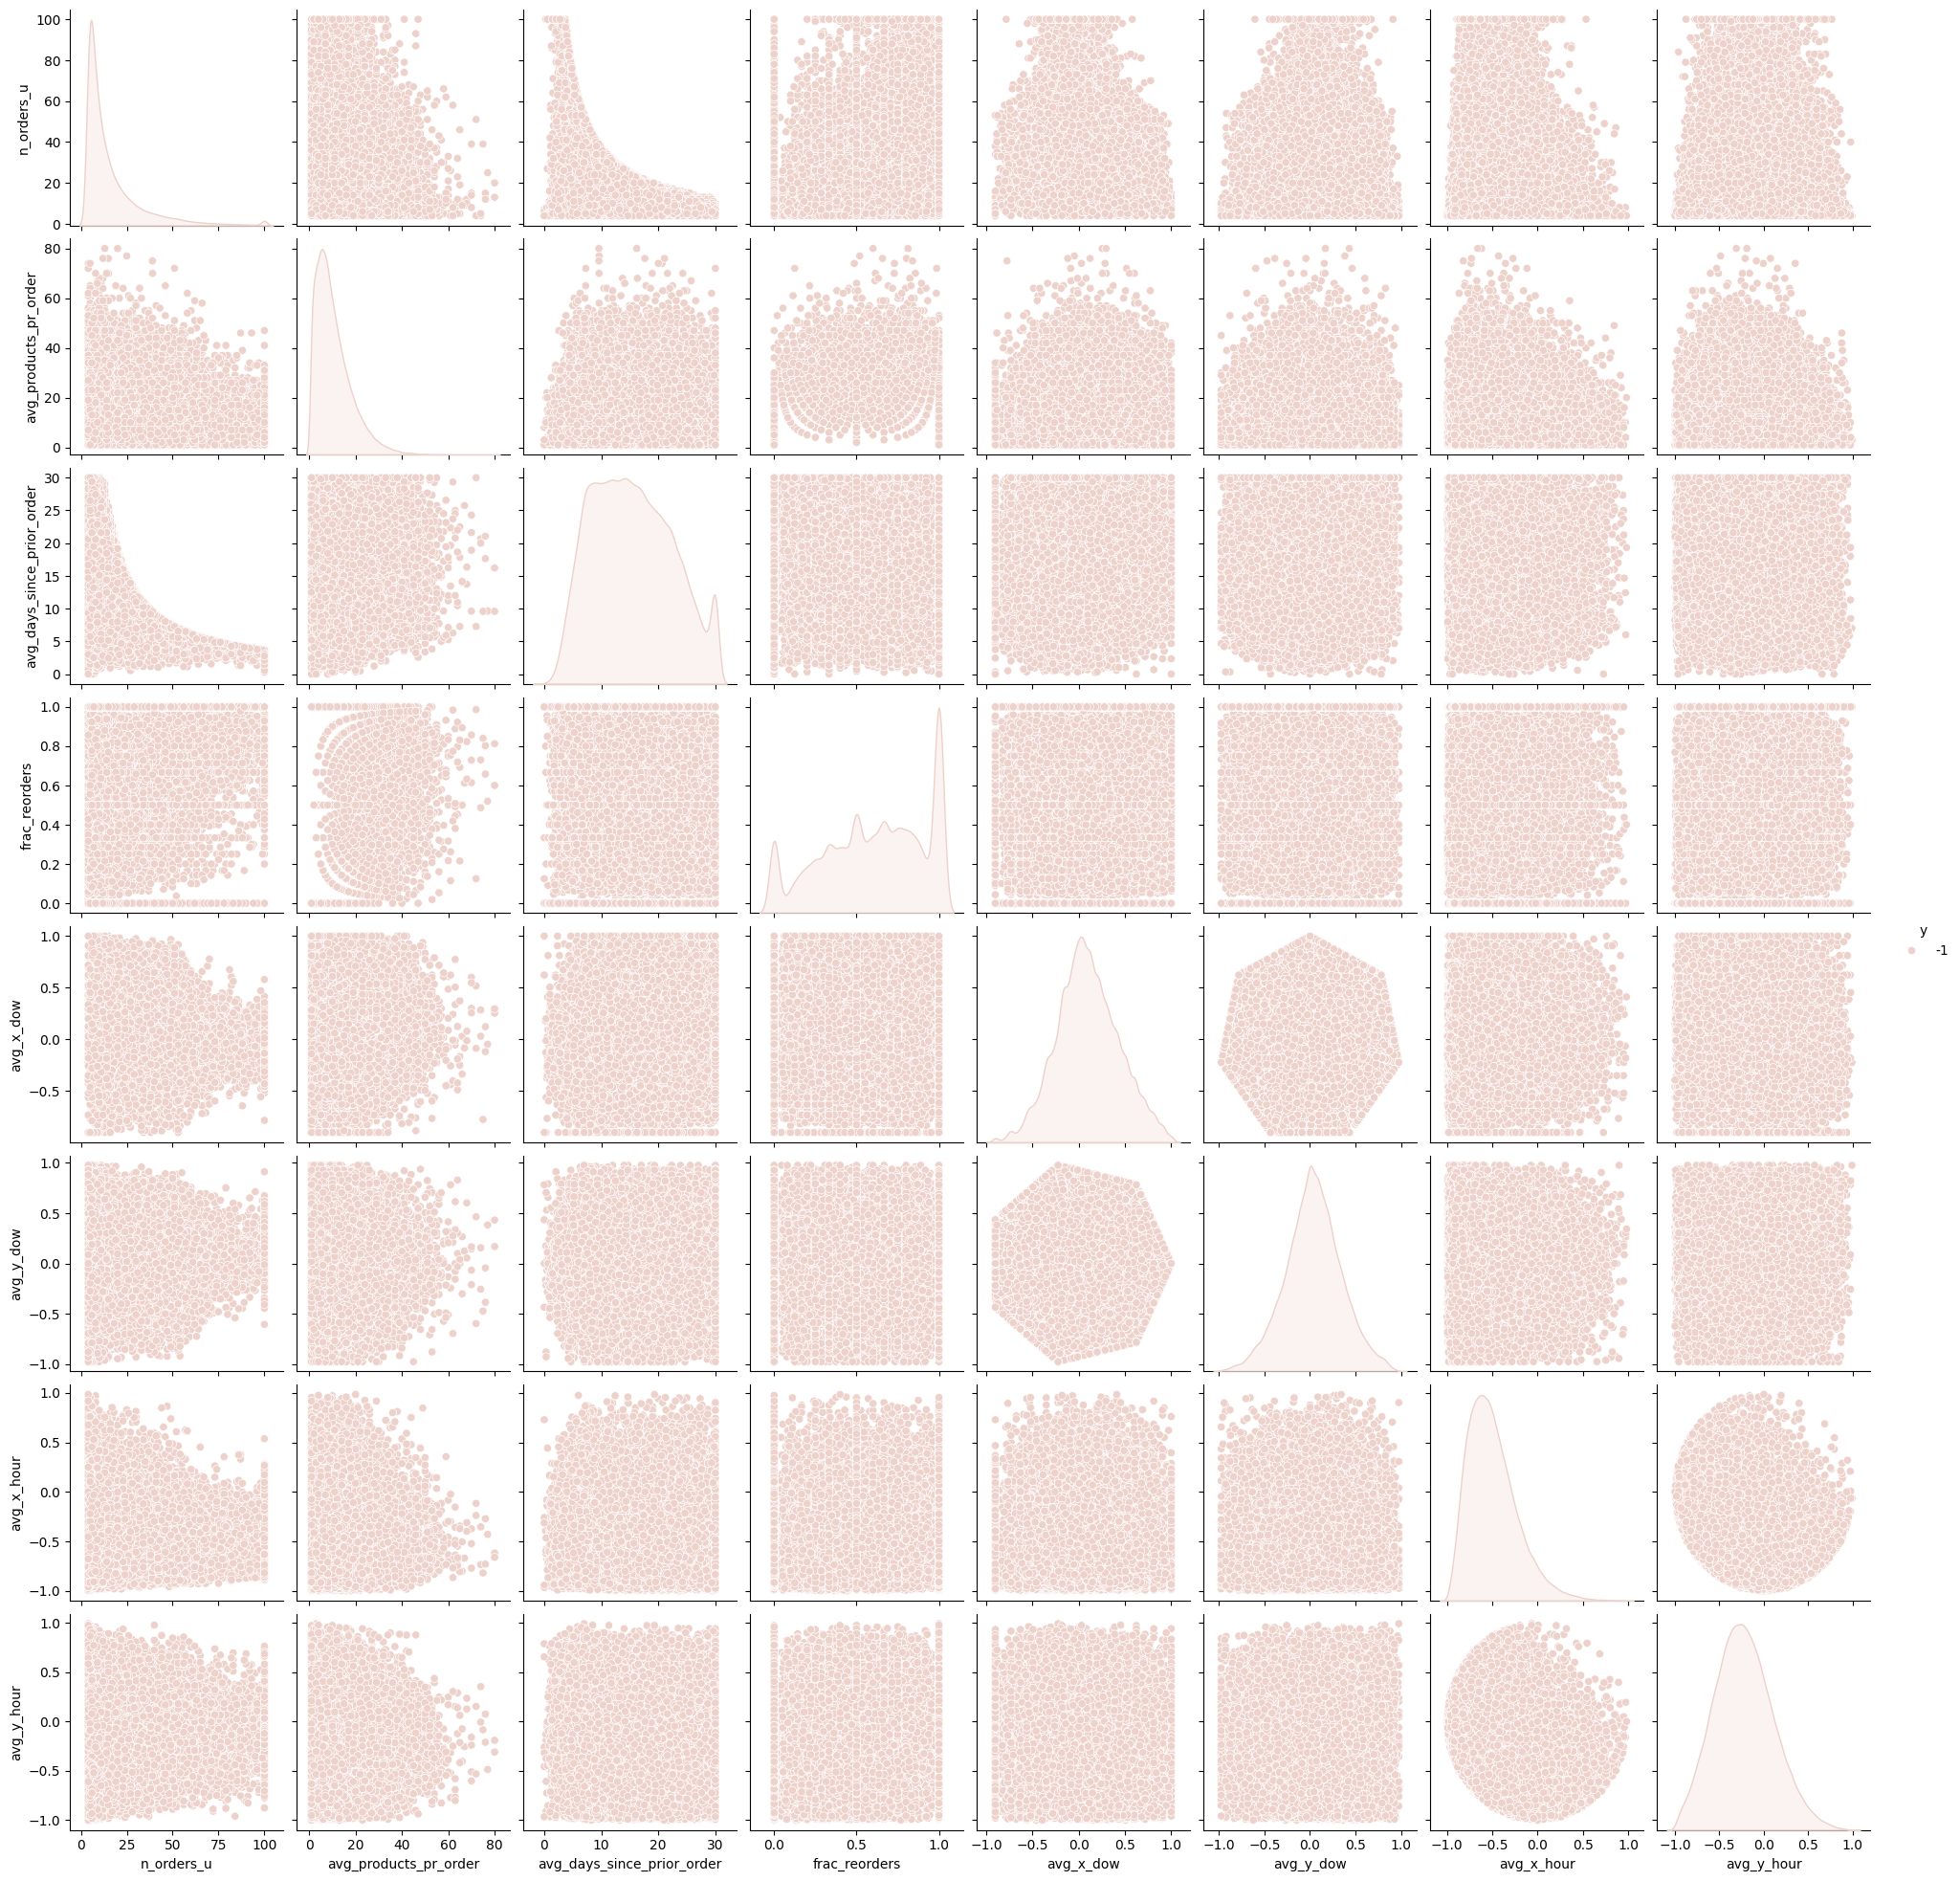

In [ ]:
import seaborn as sns
X_plot = X_sample
X_plot["y"] = y
sns.pairplot(X_plot, hue='y')

# Truncated SVD on rating matrix


In [22]:
ratings_long = pd.read_parquet(DATA_PREPROCESSED_DIR / "ratings_w_freq-0.33_w_rec-0.33_w_tfidf-0.33.pq")

def convert_to_user_term_matrix(ratings):
    """Converts from long to wide in CSR format. Input must have column names ['user', 'item', 'rating']"""
    users = ratings["user"].unique()
    item = ratings["item"].unique()
    shape = (len(users), len(item))

    # Create indices for users and movies
    user_cat = CategoricalDtype(categories=sorted(users), ordered=True)
    product_cat = CategoricalDtype(categories=sorted(item), ordered=True)
    user_index = ratings["user"].astype(user_cat).cat.codes
    product_index = ratings["item"].astype(product_cat).cat.codes

    # Conversion via COO matrix
    coo = sparse.coo_matrix((ratings_long["rating"], (user_index, product_index)), shape=shape)
    ratings_matrix = coo.tocsr()
    return ratings_matrix

ratings_matrix = convert_to_user_term_matrix(ratings_long)

In [24]:
tfidf = pd.read_parquet(DATA_PREPROCESSED_DIR / "user_product_tfidf_min_max_scaled.pq").drop("tfidf_score", axis=1)
tfidf.columns = ["user", "item", "rating"]

tfidf_matrix = convert_to_user_term_matrix(tfidf)

In [26]:
svd = TruncatedSVD(n_components=75)
X_svd = svd.fit_transform(tfidf_matrix)

umap = UMAP(n_neighbors=10, min_dist=0.5, verbose=True)
X_umap_svd = umap.fit_transform(X_svd)


UMAP(min_dist=0.5, n_neighbors=10, verbose=True)
Sat Nov 22 16:27:45 2025 Construct fuzzy simplicial set
Sat Nov 22 16:27:45 2025 Finding Nearest Neighbors
Sat Nov 22 16:27:45 2025 Building RP forest with 28 trees
Sat Nov 22 16:27:47 2025 NN descent for 18 iterations
	 1  /  18
	 2  /  18
	 3  /  18
	 4  /  18
	 5  /  18
	 6  /  18
	Stopping threshold met -- exiting after 6 iterations
Sat Nov 22 16:27:50 2025 Finished Nearest Neighbor Search
Sat Nov 22 16:27:50 2025 Construct embedding


Epochs completed:   2%| ▏          3/200 [00:00]

	completed  0  /  200 epochs


Epochs completed:  12%| █▏         24/200 [00:01]

	completed  20  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  91%| █████████  182/200 [00:12]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:13]


Sat Nov 22 16:28:29 2025 Finished embedding


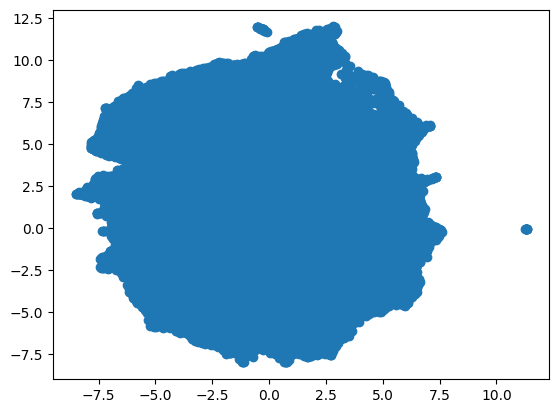

In [27]:

plt.scatter(X_umap_svd[:,0], X_umap_svd[:,1])